In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('ForeignGifts_edu.csv')

In [70]:
#Create a dataframe exclusively containing UVA.

uva_df = df[df['Institution Name'] == 'University of Virginia']

#Create a dataframe containing peer institutions/similar institutions to UVA.

peers = [
    'Duke University',
    'University of Maryland',
    'College of William & Mary',
    'University of Michigan',
    'University of California, Berkeley',
    'University of California, Los Angeles',
    'Chapel Hill',
    'University of Virginia'
]

peers_df = df[df['Institution Name'].str.contains('|'.join(peers))]


In [71]:
uva_df['Country of Giftor'].value_counts()

Country of Giftor
ENGLAND            31
ISRAEL             12
BANGLADESH         10
SWEDEN             10
FINLAND             7
KOREA               6
FRANCE              5
THE NETHERLANDS     4
TANZANIA            3
GUERNSEY            3
SINGAPORE           2
SWITZERLAND         2
JAPAN               1
BERMUDA             1
RWANDA              1
Name: count, dtype: int64

In [72]:
uva_df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)


Country of Giftor
BANGLADESH         4228589
SWEDEN             4007552
TANZANIA           2776447
SWITZERLAND        2000000
ENGLAND            1950666
GUERNSEY           1500000
FINLAND            1008384
BERMUDA             900000
KOREA               862787
SINGAPORE           805000
THE NETHERLANDS     725670
ISRAEL              623655
RWANDA              284135
JAPAN               265970
FRANCE              250383
Name: Foreign Gift Amount, dtype: int64

In [73]:
uva_df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending=False)

Country of Giftor
SWITZERLAND        1000000.000000
TANZANIA            925482.333333
BERMUDA             900000.000000
GUERNSEY            500000.000000
BANGLADESH          422858.900000
SINGAPORE           402500.000000
SWEDEN              400755.200000
RWANDA              284135.000000
JAPAN               265970.000000
THE NETHERLANDS     181417.500000
FINLAND             144054.857143
KOREA               143797.833333
ENGLAND              62924.709677
ISRAEL               51971.250000
FRANCE               50076.600000
Name: Foreign Gift Amount, dtype: float64

C:\Users\micha\AppData\Local\Temp\ipykernel_11612\4115687086.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


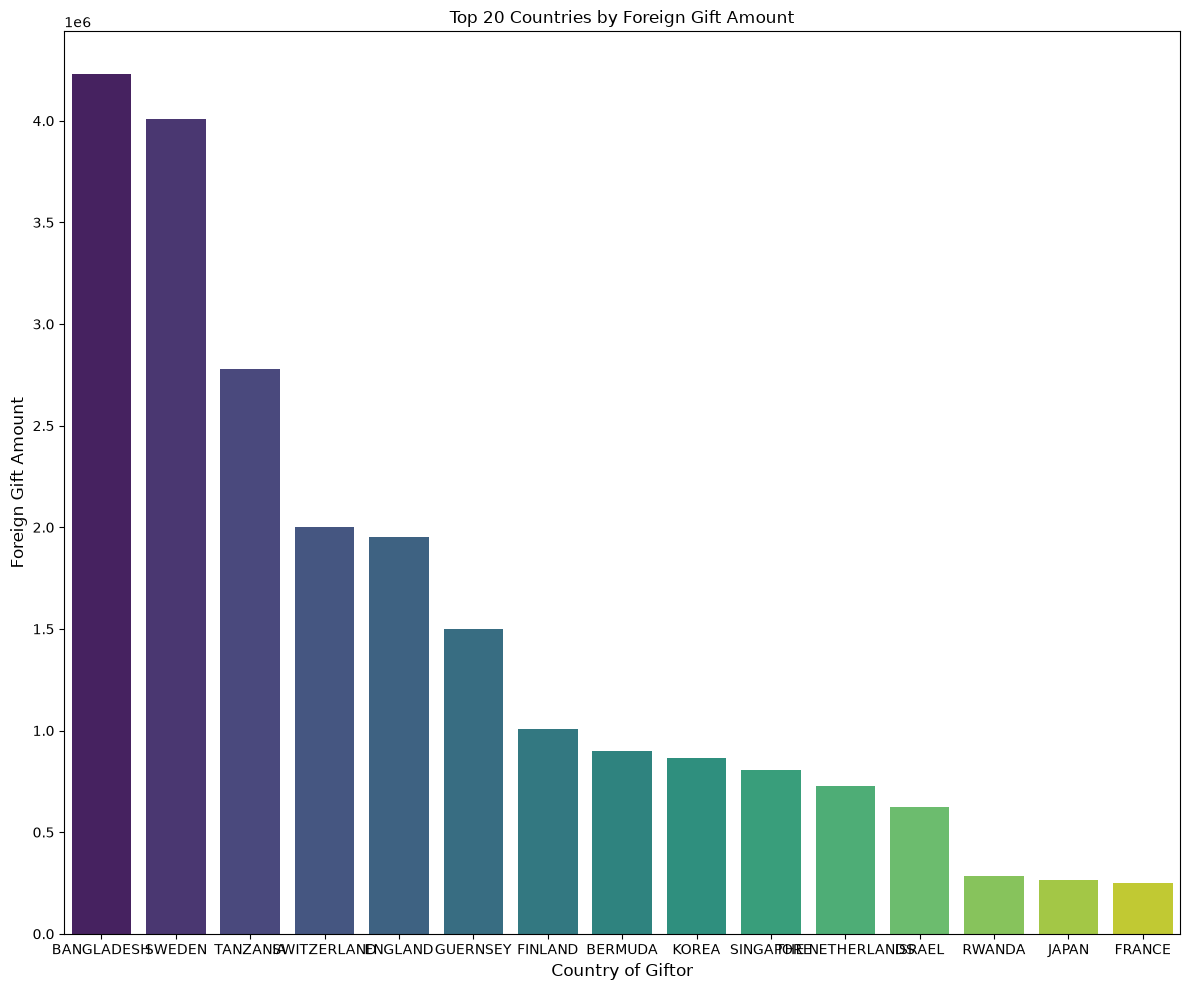

In [77]:

plt.figure(figsize=(12, 10))

top_20 = uva_df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(20)


sns.barplot(
    data=top_20.reset_index(),
    x="Country of Giftor",  
    y="Foreign Gift Amount",  
    palette="viridis"
     
)


plt.title("Top 20 Countries by Foreign Gift Amount")
plt.xlabel("Country of Giftor", fontsize=12)
plt.ylabel("Foreign Gift Amount", fontsize=12)


plt.tight_layout()
plt.show()

In [76]:
peers_df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)

Institution Name
Duke University                               343699498
University of California, Berkeley            294479904
University of Michigan - Ann Arbor            287336783
University of California, Los Angeles         242146363
University of Maryland, Baltimore              46751866
University of North Carolina - Chapel Hill     41292544
University of Maryland, College Park           29933278
University of Virginia                         22189238
College of William & Mary                       3384498
Name: Foreign Gift Amount, dtype: int64

C:\Users\micha\AppData\Local\Temp\ipykernel_11612\2866819999.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


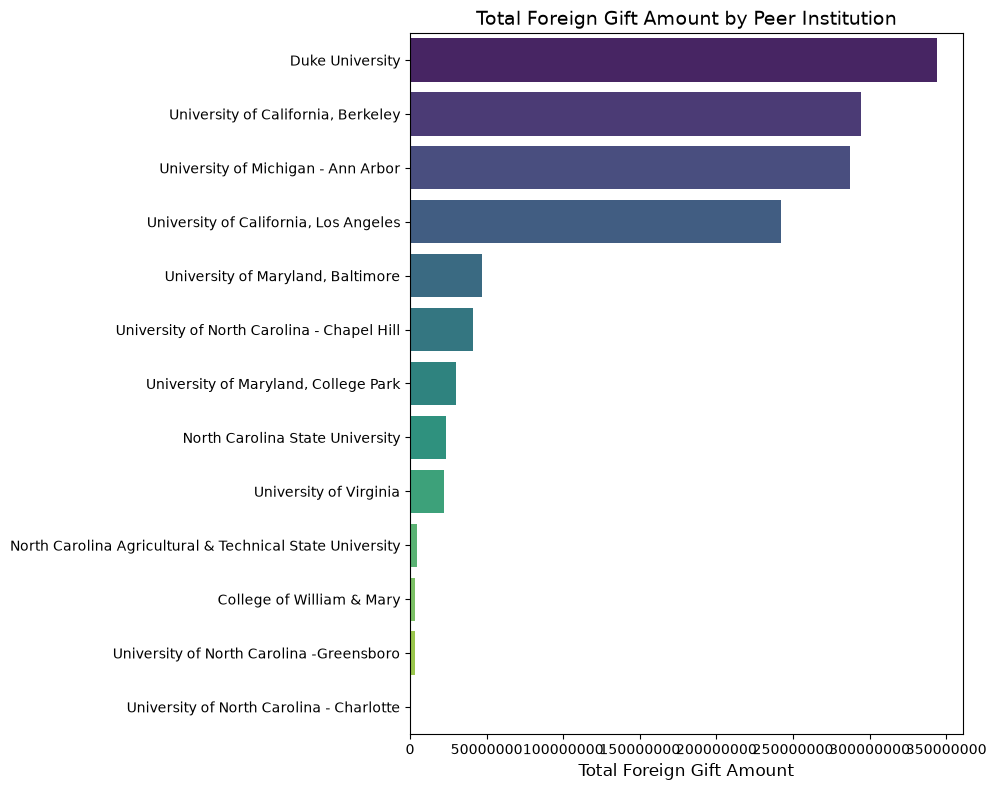

In [ ]:

peer_totals = (
    peers_df.groupby('Institution Name')['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=peer_totals,
    x='Foreign Gift Amount',
    y='Institution Name',
    palette='viridis'
)
plt.title('Total Foreign Gift Amount by Peer Institution', fontsize=14)
plt.xlabel('Total Foreign Gift Amount', fontsize=12)
plt.ylabel('')
plt.ticklabel_format(style='plain', axis='x')  
plt.tight_layout()
plt.show()

In [75]:
import pandas as pd
import plotly.graph_objects as go


#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'


N_countries = 8

top_countries = (
    peers_df.groupby(giftor)[flow]
    .sum()
    .nlargest(N_countries)
    .index
)

flows = (
    peers_df[peers_df[giftor].isin(top_countries)]
    .groupby([giftor, recipi])[flow]
    .sum()
    .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

In [82]:
unc_df = df[df['Institution Name'] == 'University of North Carolina - Chapel Hill']
unc_uva = pd.concat([unc_df, uva_df])


In [89]:
print(unc_uva.groupby('Institution Name')['Country of Giftor'].value_counts())

Institution Name                            Country of Giftor
University of North Carolina - Chapel Hill  CANADA               118
                                            ENGLAND               50
                                            ZAMBIA                36
                                            FRANCE                14
                                            BELGIUM               13
                                            DENMARK               12
                                            TAIWAN                 8
                                            SWITZERLAND            7
                                            THE NETHERLANDS        6
                                            HONG KONG              3
                                            JAPAN                  3
                                            SOUTH AFRICA           3
                                            ITALY                  2
                                         

In [90]:
print(unc_uva.groupby('Institution Name')['Foreign Gift Amount'].sum())

Institution Name
University of North Carolina - Chapel Hill    41292544
University of Virginia                        22189238
Name: Foreign Gift Amount, dtype: int64


In [88]:
summary = (
    unc_uva.groupby(['Institution Name', 'Country of Giftor'])['Foreign Gift Amount']
    .agg(
        total_amount='sum',
        mean_amount='mean',
        median_amount='median',
        num_gifts='count'
    )
    .reset_index()
    .sort_values(['Institution Name', 'total_amount'], ascending=[True, False])
)

summary

,Institution Name,Country of Giftor,total_amount,mean_amount,median_amount,num_gifts
1,University of North Carolina - Chapel Hill,CANADA,14042140,1.190012e+05,16460.0,118
16,University of North Carolina - Chapel Hill,SWITZERLAND,5371435,7.673479e+05,334400.0,7
19,University of North Carolina - Chapel Hill,ZAMBIA,4347979,1.207772e+05,64455.5,36
6,University of North Carolina - Chapel Hill,ENGLAND,2876760,5.753520e+04,5105.0,50
7,University of North Carolina - Chapel Hill,FRANCE,2631412,1.879580e+05,213349.5,14
15,University of North Carolina - Chapel Hill,SWEDEN,2476449,1.238224e+06,1238224.5,2
17,University of North Carolina - Chapel Hill,TAIWAN,2081694,2.602118e+05,300000.0,8
5,University of North Carolina - Chapel Hill,DENMARK,1167893,9.732442e+04,38241.5,12
12,University of North Carolina - Chapel Hill,MALAWI,976615,4.883075e+05,488307.5,2
18,University of North Carolina - Chapel Hill,THE NETHERLANDS,782946,1.304910e+05,22883.0,6


UVA's foreign giftors have a fairly interesting distribution, with the most amount of money coming from Bangladesh and the most individual gifts coming from England. England and Sweden are a couple of UVA's highest donors that are among the countries who gift the most, however top UVA giftors like Bangladesh and Tanzania don't appear to give as much to other institutes. 

I decided that it would be best to compare UVA to various high level state universities along with William and Mary and Duke. Most of these schools receive far more money from foreign giftors than UVA. For schools like Duke, this makes sense as Duke is the only private university listed and thus will receive much more money overall than the public institutes. 

The California schools listed also receive over ten times the amount money that UVA receives from foreign giftors, however much of this comes from China and Japan, with them each gifting tens of millions to those schools. Being in California, these schools likely have a much greater and longer connection to East Asia than UVA does. The University of Michigan is well known for its extensive ties to China, and thus has received $27 million from China that which is more than all of UVA's foreign gifts combined. Additionally, Michigan's student body is nearly twice the size of UVA's, which could also be an explanation for their much higher gift totals. 

Of the schools in the peers_df dataset, I felt the University of North Carolina at Chapel Hill was the most similar. Their student populations are fairly similar, they have similar histories and cultures, and have very similar prestige. Like UVA, UNC also receive far less in foreign gifts than Duke and the California schools, however they still receive over nearly twice the amount of money UVA does from foreign giftors, and received 286 total gifts compared to UVA's. Most of these come from Canada, UNC's top foreign giftor with 118 gifts and over 14 million dollars given. 

Based on all of this I have two main suggestions. According to the data, UVA receives no money from China despite having several hundred Chinese students. China clearly invests heavily in American universities, and UVA is obviously one of the top universities in the country, so it would be highly beneficial if UVA pursued closer ties with China. UNC clearly has a strong connection with Canadian donors, and again considering how similar of institutes UNC and UVA are, it would be feasible for UVA to pursue the same connections. UVA could even do this through UNC, and thus nearly double its foreign gift totals. 
